# Credit Risk & Loan Amount Prediction
## LendingClub Loan Data | End-to-End Machine Learning Project

**Author:** Your Name  
**Dataset:** LendingClub Accepted Loans 2007–2018  
**Last Updated:** May 2026

---

## Project Overview

This project builds a complete machine learning pipeline on real-world lending data
from LendingClub, one of the largest peer-to-peer lending platforms in the US.
The dataset contains loan applications from 2007 to 2018, covering detailed borrower
financial profiles, loan characteristics, and repayment outcomes.

We solve two distinct prediction problems:

- **Classification:** Will a borrower default on their loan?
- **Regression:** What loan amount should a borrower qualify for?

These mirror the two core decisions any lending institution makes — managing credit
risk and determining loan eligibility.

## Business Problem

When LendingClub issues a loan, it takes on financial risk on behalf of its investors.
If a borrower defaults, investors lose capital. Identifying high-risk borrowers before
a loan is issued is therefore critical to platform health.

**Classification target:** Predict whether a loan will default based on the borrower
profile and loan characteristics available at the time of application.

**Regression target:** Predict the loan amount a borrower qualifies for based on
their financial profile.

A meaningful improvement in default detection at LendingClub's scale translates
directly into reduced investor losses and better capital allocation.

## Success Metrics

### Classification
- **ROC-AUC** (primary) — measures separation between defaulters and non-defaulters
  across all thresholds, robust to class imbalance
- Precision, Recall, F1-score
- Confusion Matrix

### Regression
- **R² (R-squared)** — proportion of variance in loan amount explained by the model
- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)

### Why ROC-AUC over Accuracy?
Lending data is naturally imbalanced — most borrowers repay their loans. A naive model
that predicts "no default" for every borrower would achieve high accuracy but be
completely useless. ROC-AUC correctly captures how well the model distinguishes
defaulters from non-defaulters regardless of class distribution.

## Notebook Structure

This project is organized across 6 notebooks:

| Notebook | Description |
|---|---|
| 01_problem_statement_and_eda | Problem framing, data loading, EDA, visualizations |
| 02_hypothesis_testing_and_preprocessing | Statistical tests, cleaning, encoding |
| 03_feature_engineering_scaling_pca | Feature creation, scaling, PCA, SMOTE |
| 04_classification_models | Logistic Regression, Decision Tree, Random Forest |
| 05_regression_models | Linear, Ridge, Lasso regression |
| 06_model_evaluation_and_summary | Final evaluation, feature importance, deployment prep |

## Library Imports and Environment Setup

All libraries used throughout this notebook are imported here. Versions are printed
below for reproducibility — anyone running this project should be able to match
these versions and get identical results.

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display configuration
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# Plot style — used consistently across all notebooks in this project
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")

# Suppress non-critical warnings to keep notebook output readable
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Print library versions for reproducibility documentation
import matplotlib
import sklearn

print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("matplotlib  :", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)

numpy       : 2.1.3
pandas      : 2.2.3
matplotlib  : 3.10.0
scikit-learn: 1.6.1


## Global Random Seed

A fixed random seed is set here and will be passed to every function involving
randomness throughout this project — train/test splits, model initialization,
and resampling. This ensures results are reproducible across runs.

In [3]:
# This constant is used in every notebook that follows
RANDOM_STATE = 42

---

## Section 1: Data Loading and Initial Inspection

We load the raw dataset directly from the compressed `.gz` file. Pandas handles
`.gz` decompression natively so no manual extraction is needed.

We then perform an initial structural audit covering:
- Shape of the dataset (rows and columns)
- Data types of each column
- Volume of missing values
- A first look at the target variables

In [5]:
# Path is relative to this notebook's location inside the notebooks/ folder
# The data folder sits one level up from notebooks/
DATA_PATH = "../data/accepted_2007_to_2018Q4.csv.gz"

# Reading a .gz file — pandas decompresses it automatically
# low_memory=False prevents pandas from making incorrect dtype inferences
# on large mixed-type columns
df = pd.read_csv(DATA_PATH, low_memory=False)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset loaded successfully.
Shape: 2,260,701 rows x 151 columns


## First Look at the Data

Before any analysis, we examine the raw structure — column names, data types,
and a sample of actual values. This tells us what we are working with before
making any decisions about cleaning or filtering.

In [6]:
# View the first 5 rows to get a feel for the data
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,...,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.000,3600.000,3600.000,36 months,13.990,123.030,C,C4,leadman,10+ years,MORTGAGE,55000.000,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.910,0.000,Aug-2003,675.000,679.000,1.000,30.000,NaN,7.000,0.000,2765.000,29.700,13.000,w,0.000,0.000,4421.724,4421.720,3600.000,821.720,0.000,0.000,0.000,Jan-2019,122.670,NaN,...,4.000,7.000,0.000,0.000,0.000,3.000,76.900,0.000,0.000,0.000,178050.000,7746.000,2400.000,13734.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.000,24700.000,24700.000,36 months,11.990,820.280,C,C1,Engineer,10+ years,MORTGAGE,65000.000,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.060,1.000,Dec-1999,715.000,719.000,4.000,6.000,NaN,22.000,0.000,21470.000,19.200,38.000,w,0.000,0.000,25679.660,25679.660,24700.000,979.660,0.000,0.000,0.000,Jun-2016,926.350,NaN,...,5.000,22.000,0.000,0.000,0.000,2.000,97.400,7.700,0.000,0.000,314017.000,39475.000,79300.000,24667.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.000,20000.000,20000.000,60 months,10.780,432.660,B,B4,truck driver,10+ years,MORTGAGE,63000.000,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.780,0.000,Aug-2000,695.000,699.000,0.000,NaN,NaN,6.000,0.000,7869.000,56.200,18.000,w,0.000,0.000,22705.924,22705.920,20000.000,2705.920,0.000,0.000,0.000,Jun-2017,15813.300,NaN,...,3.000,6.000,0.000,0.000,0.000,0.000,100.000,50.000,0.000,0.000,218418.000,18696.000,6200.000,14877.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.000,35000.000,35000.000,60 months,14.850,829.900,C,C5,Information Systems Officer,10+ years,MORTGAGE,110000.000,Source Verified,Dec-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,076xx,NJ,17.060,0.000,Sep-2008,785.000,789.000,0.000,NaN,NaN,13.000,0.000,7802.000,11.600,17.000,w,15897.650,15897.650,31464.

In [8]:
# Check data types and non-null counts across all 151 columns
df.info(verbose =True , show_counts= True )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 151 columns):
 #    Column                                      Non-Null Count    Dtype  
---   ------                                      --------------    -----  
 0    id                                          2260701 non-null  object 
 1    member_id                                   0 non-null        float64
 2    loan_amnt                                   2260668 non-null  float64
 3    funded_amnt                                 2260668 non-null  float64
 4    funded_amnt_inv                             2260668 non-null  float64
 5    term                                        2260668 non-null  object 
 6    int_rate                                    2260668 non-null  float64
 7    installment                                 2260668 non-null  float64
 8    grade                                       2260668 non-null  object 
 9    sub_grade                                   

## Filtering to 2015–2018

The full dataset spans 2007 to 2018. We filter to 2015–2018 for two reasons:

1. **Data quality:** Earlier years (2007–2012) have significantly more missing values
   and fewer features recorded, as LendingClub's data collection improved over time.
2. **Relevance:** More recent lending behavior better reflects current credit market
   conditions and borrower profiles.

This still gives us a large, rich dataset while keeping compute time manageable.

In [11]:
# Convert issue_d to datetime — errors="coerce" turns unparseable values to NaT
# instead of raising an error, which handles any stray nulls or malformed entries
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y", errors="coerce")

# Drop rows where date conversion failed (NaT values)
df = df[df["issue_d"].notna()]

# Filter to 2015 onwards
df = df[df["issue_d"].dt.year >= 2015]

print(f"Filtered dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Filtered dataset shape: 1,794,323 rows x 151 columns


## Missing Value Audit

With 151 columns, many will have substantial missing data. We compute the
percentage of missing values per column and identify columns that are too
sparse to be useful.

Our threshold: any column missing more than 40% of its values will be dropped
in the preprocessing notebook. This is a deliberate choice — imputing more
than 40% of a column introduces more noise than signal.

In [12]:
# Compute missing percentage for each column, sorted descending
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().sum() / len(df)) * 100
})

missing = missing[missing["missing_count"] > 0].sort_values("missing_pct", ascending=False)

print(f"Columns with at least one missing value: {len(missing)} out of {df.shape[1]}")
print()
print(missing.head(30))

Columns with at least one missing value: 77 out of 151

                                            missing_count  missing_pct
member_id                                         1794323      100.000
desc                                              1794255       99.996
orig_projected_additional_accrued_interest        1786140       99.544
hardship_status                                   1783989       99.424
hardship_end_date                                 1783989       99.424
hardship_amount                                   1783989       99.424
hardship_dpd                                      1783989       99.424
hardship_length                                   1783989       99.424
payment_plan_start_date                           1783989       99.424
hardship_last_payment_amount                      1783989       99.424
hardship_payoff_balance_amount                    1783989       99.424
deferral_term                                     1783989       99.424
hardship_reason      

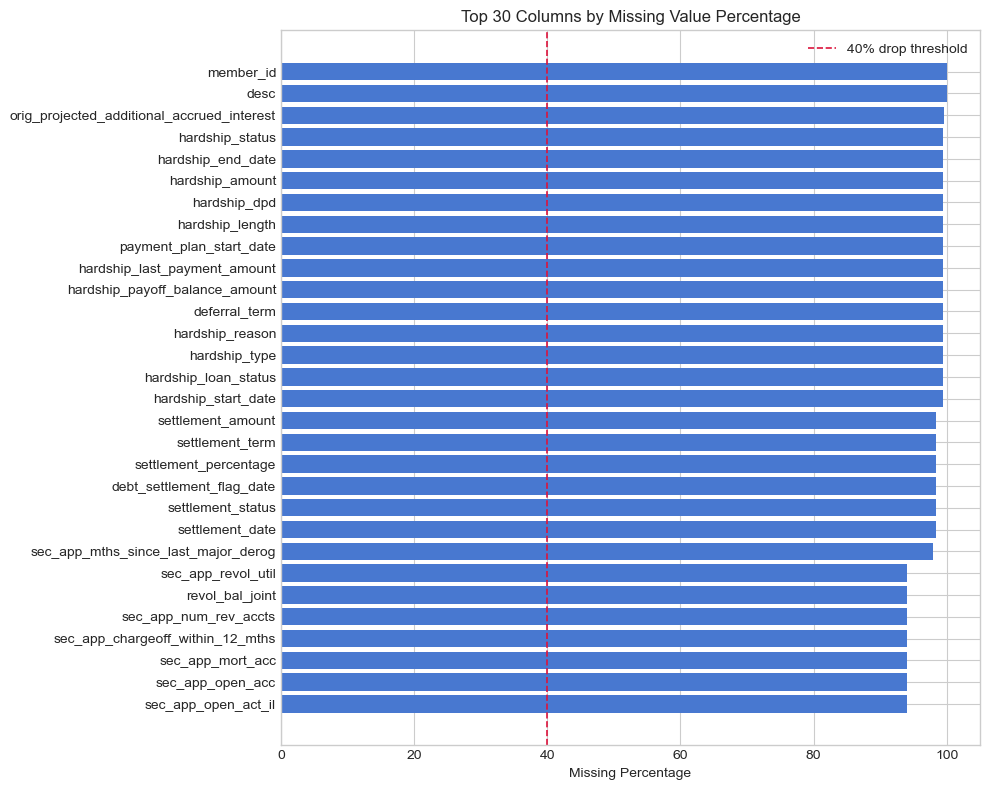

Columns exceeding 40% missing threshold: 44


In [13]:
# Visualize the top 30 columns by missing percentage
top_missing = missing.head(30)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(top_missing.index, top_missing["missing_pct"],
        color=sns.color_palette("muted")[0])

# Reference line marking our 40% drop threshold
ax.axvline(x=40, color="crimson", linestyle="--",
           linewidth=1.2, label="40% drop threshold")

ax.set_xlabel("Missing Percentage")
ax.set_title("Top 30 Columns by Missing Value Percentage")
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Count how many columns fall above the threshold
cols_to_drop = missing[missing["missing_pct"] > 40]
print(f"Columns exceeding 40% missing threshold: {len(cols_to_drop)}")

## Target Variable Inspection

This project has two prediction targets:

- **Classification target:** `loan_status` — whether a borrower defaulted
- **Regression target:** `loan_amnt` — the loan amount in USD

We inspect both now to understand their distributions and identify
how we will construct the binary default label from `loan_status`.

In [14]:
# Examine all unique values in loan_status and their counts
# This determines how we construct the binary default label
print("loan_status value counts:")
print()
print(df["loan_status"].value_counts())
print()
print(f"Total unique statuses: {df['loan_status'].nunique()}")

loan_status value counts:

loan_status
Current               866392
Fully Paid            702191
Charged Off           192060
Late (31-120 days)     21130
In Grace Period         8235
Late (16-30 days)       4276
Default                   39
Name: count, dtype: int64

Total unique statuses: 7


In [15]:
# Define the mapping from loan_status to binary default label
# Only rows with a known final outcome are retained

# Loans confirmed as defaulted or severely delinquent
default_statuses = ["Charged Off", "Default", "Late (31-120 days)"]

# Loans confirmed as fully repaid
paid_statuses = ["Fully Paid"]

# Filter to rows with a known outcome only
# Drops: Current, In Grace Period, Late (16-30 days)
df = df[df["loan_status"].isin(default_statuses + paid_statuses)]

# Create binary target column
# 1 = defaulted, 0 = fully paid
df["default"] = df["loan_status"].isin(default_statuses).astype(int)

print(f"Rows after outcome filtering: {df.shape[0]:,}")
print()
print("Binary label distribution:")
print(df["default"].value_counts())
print()
print(f"Default rate: {df['default'].mean() * 100:.2f}%")

Rows after outcome filtering: 915,420

Binary label distribution:
default
0    702191
1    213229
Name: count, dtype: int64

Default rate: 23.29%


In [16]:
# Summary statistics for the regression target
print("Loan Amount Summary Statistics:")
print()
print(df["loan_amnt"].describe())

Loan Amount Summary Statistics:

count   915420.000
mean     14590.058
std       8964.114
min       1000.000
25%       7800.000
50%      12000.000
75%      20000.000
max      40000.000
Name: loan_amnt, dtype: float64


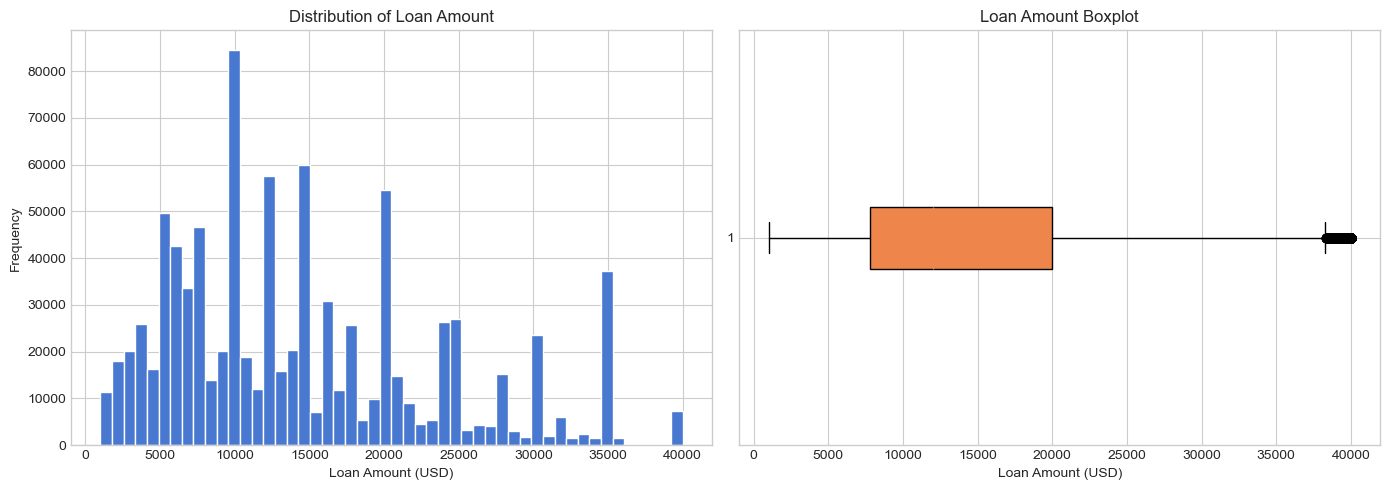

In [17]:
# Visualize loan amount distribution using histogram and boxplot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram shows the overall shape and where values concentrate
axes[0].hist(df["loan_amnt"], bins=50,
             color=sns.color_palette("muted")[0], edgecolor="white")
axes[0].set_xlabel("Loan Amount (USD)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Loan Amount")

# Boxplot shows median, interquartile range and outliers
axes[1].boxplot(df["loan_amnt"].dropna(), vert=False,
                patch_artist=True,
                boxprops=dict(facecolor=sns.color_palette("muted")[1]))
axes[1].set_xlabel("Loan Amount (USD)")
axes[1].set_title("Loan Amount Boxplot")

plt.tight_layout()
plt.show()

## Section 2: Exploratory Data Analysis

We explore the key features of the dataset to understand distributions,
relationships between variables, and early signals of what drives default.

This section covers:
- Distribution of core borrower features
- Default rate across categorical variables
- Correlation structure of numerical features
- Relationship between key features and both targets

In [19]:
# Select the core numerical features for initial EDA
# These are the most financially meaningful borrower attributes
numerical_features = [
    "loan_amnt",      # loan amount requested
    "annual_inc",     # borrower annual income
    "dti",            # debt to income ratio
    "int_rate",       # interest rate assigned
    "installment",    # monthly payment amount
    "revol_util",     # revolving credit utilization
    "fico_range_low"  # lower bound of borrower credit score
]

# Summary statistics for all core numerical features at once
print("Summary Statistics for Core Numerical Features:")
print()
print(df[numerical_features].describe())

Summary Statistics for Core Numerical Features:

       loan_amnt   annual_inc        dti   int_rate  installment  revol_util  \
count 915420.000   915420.000 915022.000 915420.000   915420.000  914826.000   
mean   14590.058    77820.542     18.877     13.032      442.802      49.668   
std     8964.114    76840.233     12.650      4.962      270.112      24.641   
min     1000.000        0.000     -1.000      5.310       14.010       0.000   
25%     7800.000    46700.000     12.070      9.170      246.620      31.000   
50%    12000.000    65000.000     18.080     12.390      374.200      49.400   
75%    20000.000    93000.000     24.830     15.610      592.180      68.400   
max    40000.000 10999200.000    999.000     30.990     1719.830     193.000   

       fico_range_low  
count      915420.000  
mean          696.058  
std            32.276  
min           660.000  
25%           670.000  
50%           690.000  
75%           710.000  
max           845.000  


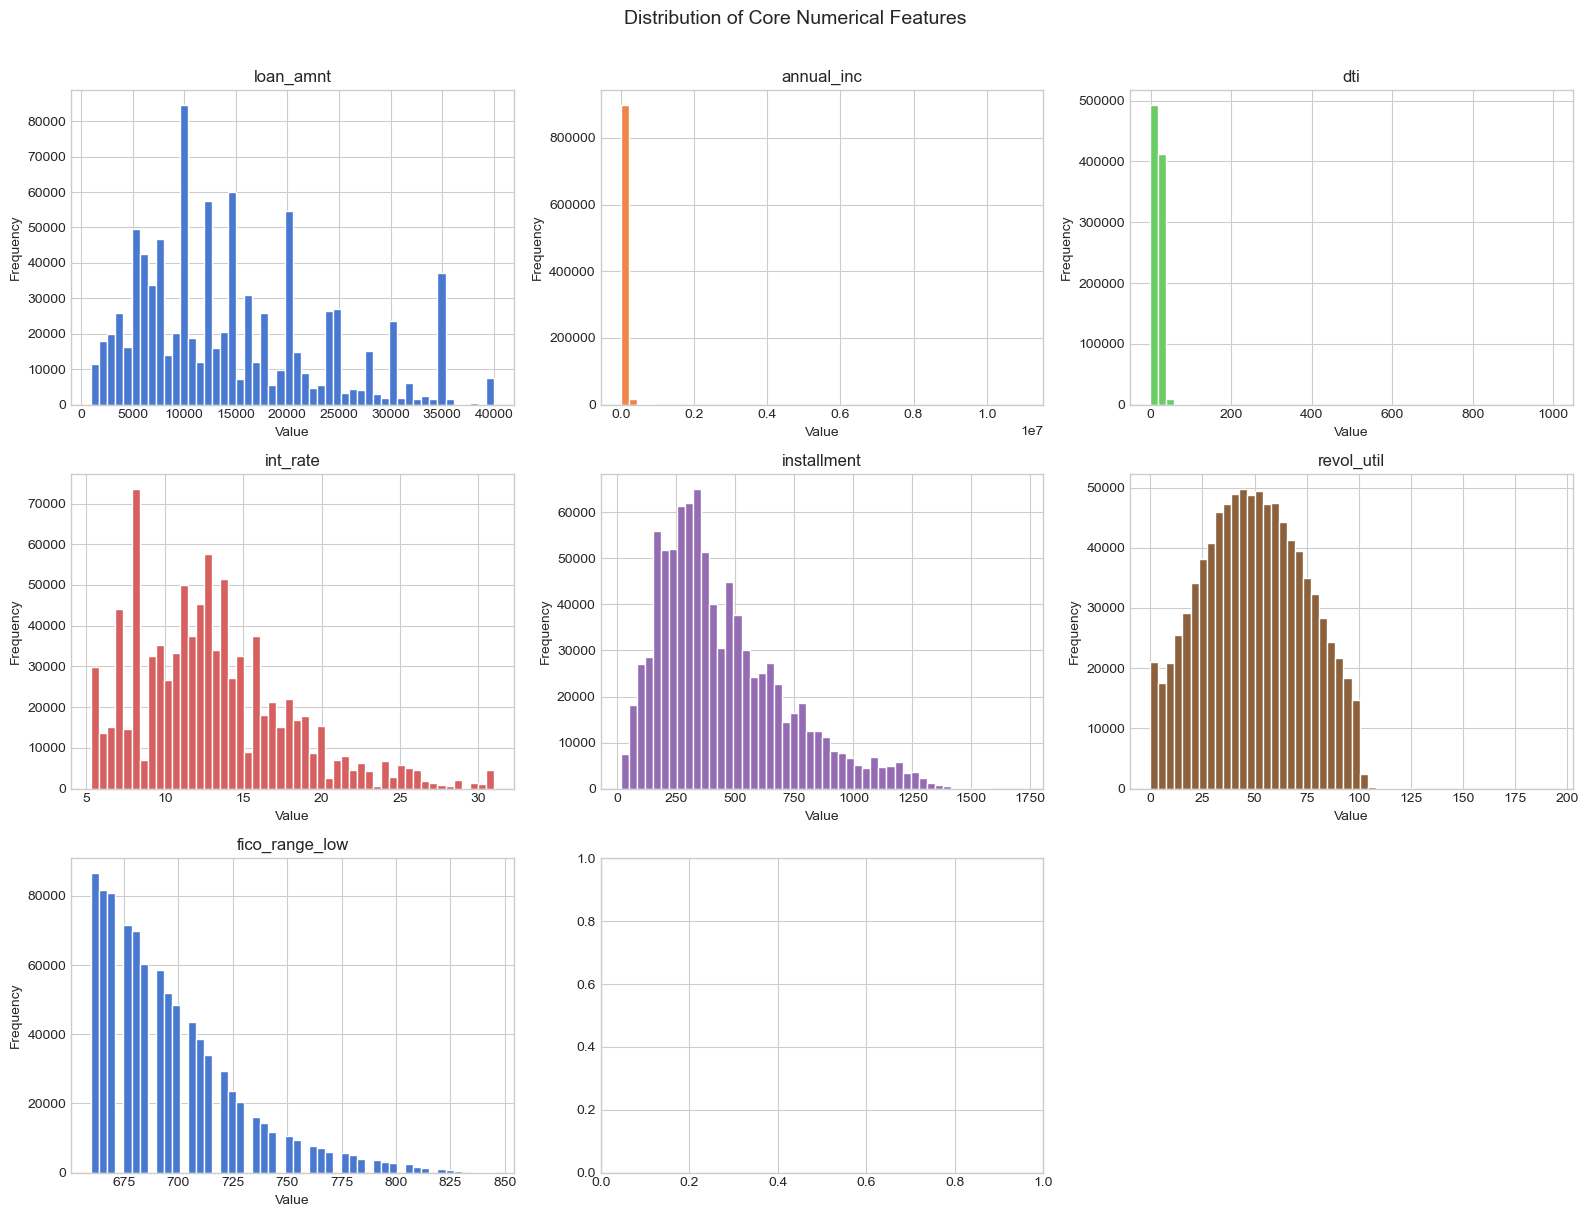

In [20]:
# Visualize distributions of core numerical features
# Using a grid of histograms to compare shapes side by side
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    axes[i].hist(df[col].dropna(), bins=50,
                 color=sns.color_palette("muted")[i % 6],
                 edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

# Hide the unused 9th subplot
axes[-1].set_visible(False)

fig.suptitle("Distribution of Core Numerical Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

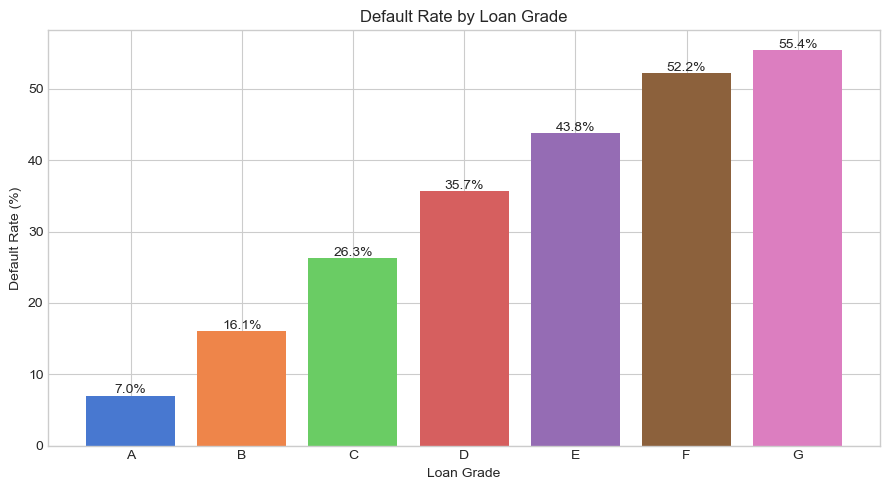

In [21]:
# Visualize default rate across loan grade
# Grade is LendingClub's own internal risk rating (A = safest, G = riskiest)
# This is one of the most important categorical features in the dataset
grade_default = df.groupby("grade")["default"].mean().sort_index() * 100

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(grade_default.index, grade_default.values,
              color=sns.color_palette("muted"))

# Annotate each bar with the default rate value
for bar, val in zip(bars, grade_default.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", fontsize=10)

ax.set_xlabel("Loan Grade")
ax.set_ylabel("Default Rate (%)")
ax.set_title("Default Rate by Loan Grade")

plt.tight_layout()
plt.show()

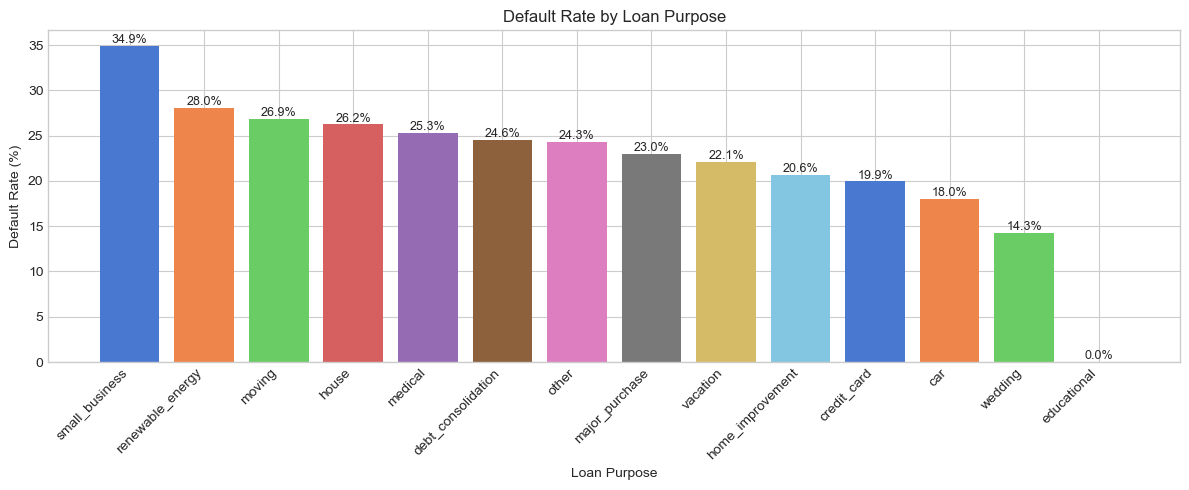

In [22]:
# Default rate by loan purpose
# Purpose tells us why the borrower took the loan
# We expect debt consolidation to dominate and show interesting default patterns
purpose_default = (df.groupby("purpose")["default"]
                     .mean()
                     .sort_values(ascending=False) * 100)

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(purpose_default.index, purpose_default.values,
              color=sns.color_palette("muted"))

for bar, val in zip(bars, purpose_default.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", fontsize=9)

ax.set_xlabel("Loan Purpose")
ax.set_ylabel("Default Rate (%)")
ax.set_title("Default Rate by Loan Purpose")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

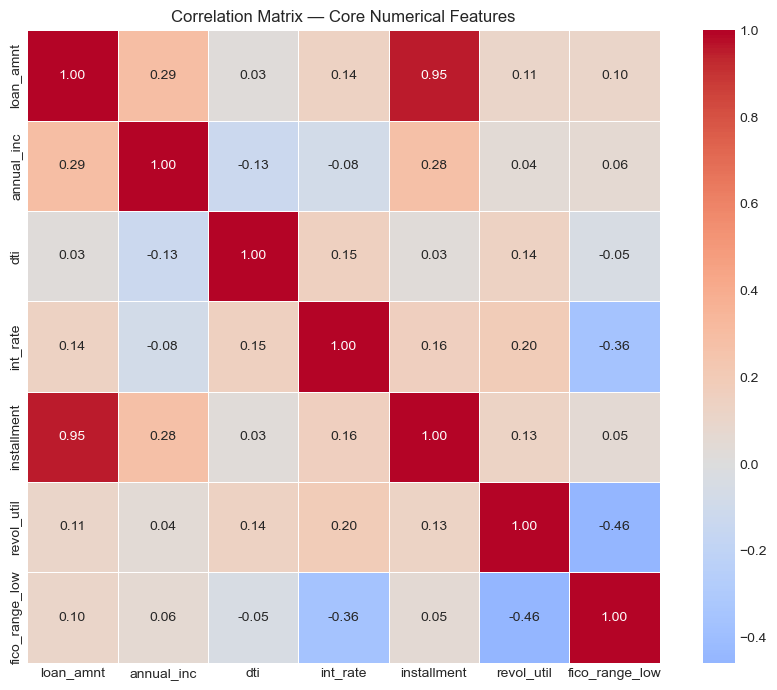

In [23]:
# Correlation heatmap for numerical features
# This shows us which features are correlated with each other
# High correlation between features is exactly why PCA becomes justified later
corr_matrix = df[numerical_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax)

ax.set_title("Correlation Matrix — Core Numerical Features")

plt.tight_layout()
plt.show()

## Section 3: EDA Summary and Key Findings

Before moving to hypothesis testing and preprocessing, we document the key
findings from our exploratory analysis. These findings directly inform every
decision made in subsequent notebooks.

### Data Quality Issues Identified
- `annual_inc` contains extreme outliers up to $10.99M — requires capping
- `dti` contains physically impossible values of 999 and negative values — requires cleaning
- `revol_util` contains values above 100% — requires investigation and capping
- 44 columns exceed the 40% missing value threshold — will be dropped in notebook 02

### Target Variable Findings
- Overall default rate: 23.29% — moderate class imbalance, manageable with class weights
- `loan_amnt` is right-skewed with round-number clustering — log transformation needed
  before regression modeling

### Key Predictive Signals Found
- Loan grade shows a perfect monotonic relationship with default rate (7% at A to 55.4% at G)
- Small business loans carry the highest default risk by purpose (34.9%)
- `loan_amnt` and `installment` are 0.95 correlated — strong justification for PCA
- `fico_range_low` negatively correlates with both `int_rate` and `revol_util` as expected

### Next Steps
Notebook 02 covers hypothesis testing to statistically validate these visual findings,
followed by systematic data cleaning and preprocessing.

In [24]:
# Save the filtered dataframe so notebook 02 can load it directly
# This avoids reloading and refiltering the full 2.2M row file every time
df.to_parquet("../data/loans_filtered.parquet", index=False)

print(f"Filtered dataset saved successfully.")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Filtered dataset saved successfully.
Shape: 915,420 rows x 152 columns
